In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import sys
sys.path.append('../../knn_classifier')
from knn import KNN_Weighted

In [4]:
angry_train = np.load('../../data/selected_landmarks_train/angry_landmarks.npy')
disgust_train = np.load('../../data/selected_landmarks_train/disgust_landmarks.npy')
fear_train = np.load('../../data/selected_landmarks_train/fear_landmarks.npy') 
happy_train = np.load('../../data/selected_landmarks_train/happy_landmarks.npy')
neutral_train = np.load('../../data/selected_landmarks_train/neutral_landmarks.npy')
sad_train = np.load('../../data/selected_landmarks_train/sad_landmarks.npy')
suprise_train = np.load('../../data/selected_landmarks_train/surprise_landmarks.npy')

angry_test = np.load('../../data/selected_landmarks_test/angry_landmarks.npy')
disgust_test = np.load('../../data/selected_landmarks_test/disgust_landmarks.npy')
fear_test = np.load('../../data/selected_landmarks_test/fear_landmarks.npy') 
happy_test = np.load('../../data/selected_landmarks_test/happy_landmarks.npy')
neutral_test = np.load('../../data/selected_landmarks_test/neutral_landmarks.npy')
sad_test = np.load('../../data/selected_landmarks_test/sad_landmarks.npy')
suprise_test = np.load('../../data/selected_landmarks_test/surprise_landmarks.npy')

In [6]:
train_data = {
    'angry': angry_train,
    'disgust': disgust_train,
    'fear': fear_train,
    'happy': happy_train,
    'neutral': neutral_train,
    'sad': sad_train,
    'suprise': suprise_train
}

test_data = {
    'angry': angry_test,
    'disgust': disgust_test,
    'fear': fear_test,
    'happy': happy_test,
    'neutral': neutral_test,
    'sad': sad_test,
    'suprise': suprise_test
}

In [7]:
train_X_list = []
train_y_list = []

for emotion, data in train_data.items():
    train_X_list.append(data.reshape(data.shape[0], -1))
    train_y_list.append(np.full((data.shape[0],), emotion))

X_train = np.concatenate(train_X_list, axis=0)
y_train = np.concatenate(train_y_list, axis=0)

test_X_list = []
test_y_list = []

for emotion, data in test_data.items():
    test_X_list.append(data.reshape(data.shape[0], -1))
    test_y_list.append(np.full((data.shape[0],), emotion))

X_test = np.concatenate(test_X_list, axis=0)
y_test = np.concatenate(test_y_list, axis=0)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
knn = KNN_Weighted(k=97)
knn.fit(X_train_scaled, y_train)

knn_predictions = knn.predict(X_test_scaled)

cm = confusion_matrix(y_test, knn_predictions, labels=knn.classes_)

making prediction:
finish calculating


Classification Report:

              precision    recall  f1-score   support

       angry     0.4257    0.1509    0.2228       835
     disgust     1.0000    0.2887    0.4480        97
        fear     0.3994    0.1468    0.2147       933
       happy     0.5347    0.8319    0.6510      1713
     neutral     0.3557    0.5919    0.4444      1181
         sad     0.4159    0.2486    0.3112      1094
     suprise     0.6402    0.5597    0.5973       779

    accuracy                         0.4709      6632
   macro avg     0.5388    0.4026    0.4128      6632
weighted avg     0.4697    0.4709    0.4336      6632

Overall Metrics:
Accuracy: 0.4708986731001206
Macro F1-score: 0.4127677562401237
Weighted F1-score: 0.4335827293175206
Macro Precision: 0.5388091512371308
Macro Recall: 0.4026374503382831


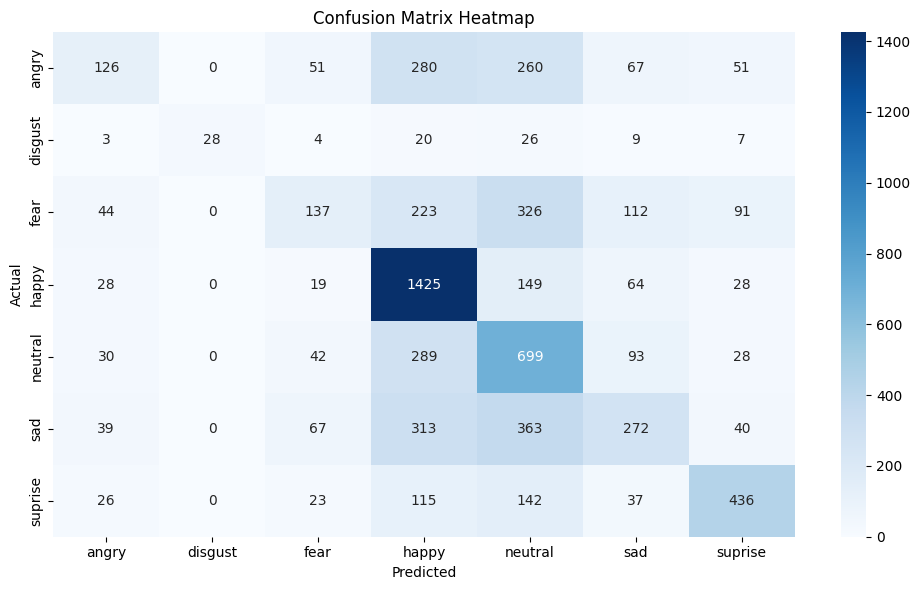

In [10]:
print("Classification Report:\n")
report = classification_report(y_test, knn_predictions, digits=4, zero_division=0)
print(report)

print("Overall Metrics:")
print("Accuracy:", accuracy_score(y_test, knn_predictions))
print("Macro F1-score:", f1_score(y_test, knn_predictions, average='macro'))
print("Weighted F1-score:", f1_score(y_test, knn_predictions, average='weighted'))
print("Macro Precision:", precision_score(y_test, knn_predictions, average='macro'))
print("Macro Recall:", recall_score(y_test, knn_predictions, average='macro'))

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()  
    